In [1]:
# Credit Card Fraud Detection 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load Dataset
df = pd.read_csv("C:/Users/HP/Desktop/Internship Final Submission/Credit Card Fraud Analysis/1_credit_card_fraud_ Original Dataset.csv")
print(df.columns.tolist())

['transaction_id', 'amount', 'transaction_hour', 'merchant_category', 'foreign_transaction', 'location_mismatch', 'device_trust_score', 'velocity_last_24h', 'cardholder_age', 'Class']


In [3]:
# Basic Information
print(df.head())
print(df.info())
print(df.describe())

   transaction_id  amount  transaction_hour merchant_category  \
0               1   84.47                22       Electronics   
1               2  541.82                 3            Travel   
2               3  237.01                17           Grocery   
3               4  164.33                 4           Grocery   
4               5   30.53                15              Food   

   foreign_transaction  location_mismatch  device_trust_score  \
0                    0                  0                  66   
1                    1                  0                  87   
2                    0                  0                  49   
3                    0                  1                  72   
4                    0                  0                  79   

   velocity_last_24h  cardholder_age  Class  
0                  3              40      0  
1                  1              64      0  
2                  1              61      0  
3                  3              

In [4]:
#Perform EDA Analysis
 # 1.TRANSACTION ANALYSIS

total_transactions = len(df)
fraud_transactions = df["Class"].sum()
fraud_percentage = (fraud_transactions / total_transactions) * 100

print("\nTransaction Analysis")
print("Total Transactions :", total_transactions)
print("Total Fraud Transactions :", fraud_transactions)
print("Fraud Percentage : {:.4f}%".format(fraud_percentage))


Transaction Analysis
Total Transactions : 10000
Total Fraud Transactions : 151
Fraud Percentage : 1.5100%


In [5]:
 # 2.AMOUNT ANALYSIS

print("\namount Analysis")
print("Maximum Transaction :", df["amount"].max())
print("Minimum Transaction :", df["amount"].min())
print("Average Transaction :", df["amount"].mean())
print("Median Transaction :", df["amount"].median())


amount Analysis
Maximum Transaction : 1471.04
Minimum Transaction : 0.0
Average Transaction : 175.94984899999997
Median Transaction : 122.095


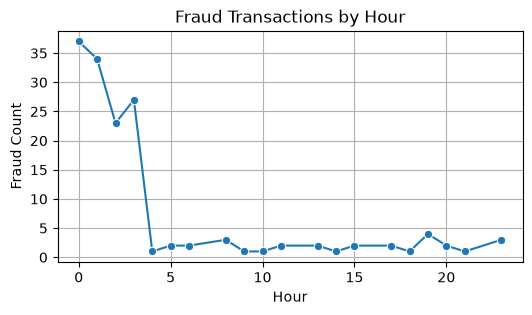

In [6]:
# 3.TIME ANALYSIS

# Fraud by Hour Plot
df["Hour"] = df["transaction_hour"] % 24
fraud = df[df["Class"] == 1]
fraud_by_hour = fraud.groupby("Hour").size()
plt.figure(figsize=(6,3))
sns.lineplot(x=fraud_by_hour.index,
             y=fraud_by_hour.values,
             marker='o')
plt.title("Fraud Transactions by Hour")
plt.xlabel("Hour")
plt.ylabel("Fraud Count")
plt.grid(True)
plt.show()



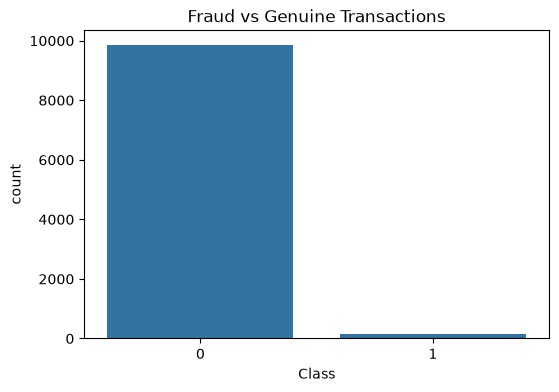

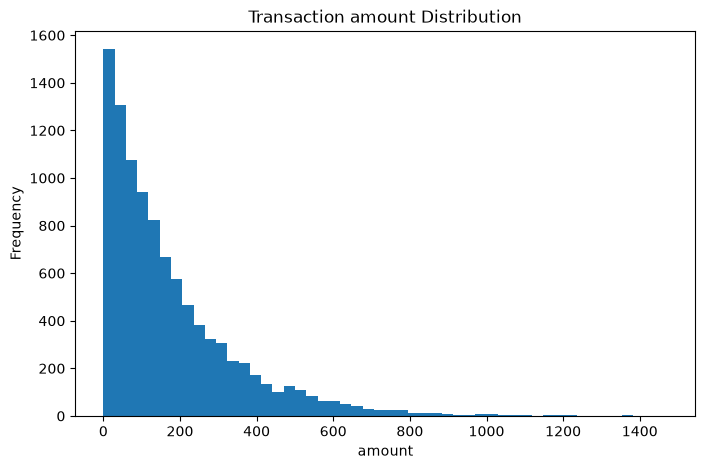

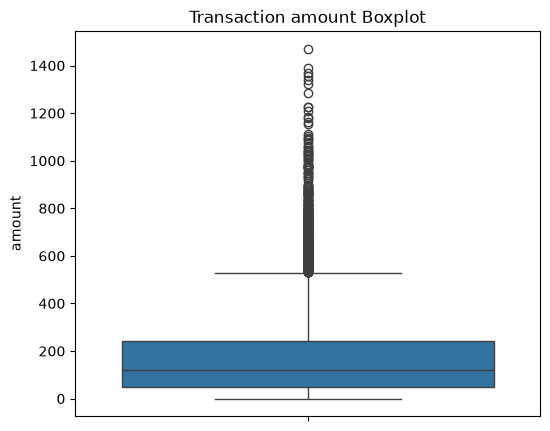

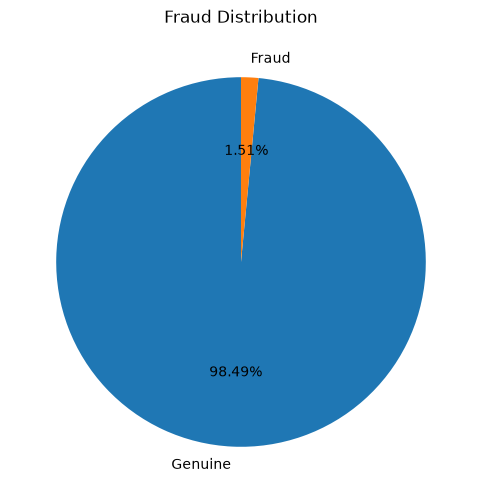

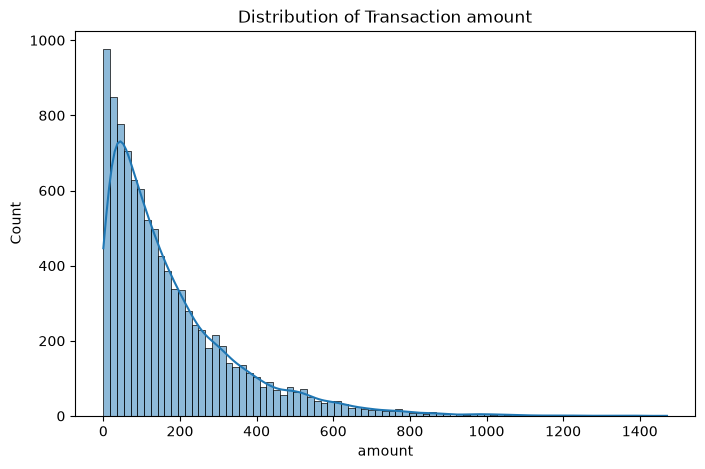

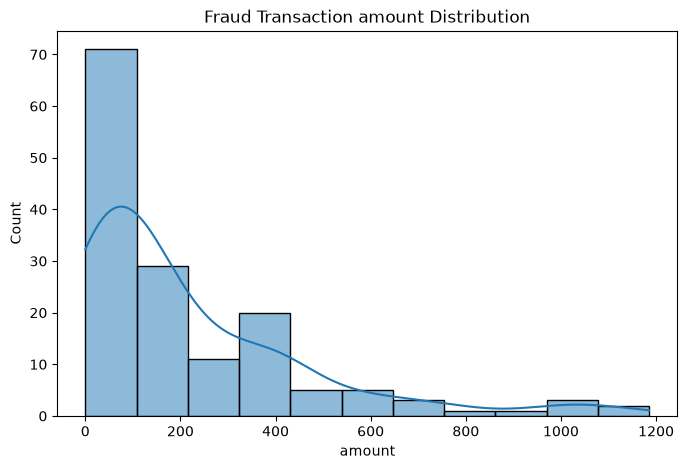

In [7]:
# 4. VISUALIZATION

# Count Plot
plt.figure(figsize=(6,4))
sns.countplot(x="Class", data=df)
plt.title("Fraud vs Genuine Transactions")
plt.show()

# Histogram
plt.figure(figsize=(8,5))
plt.hist(df["amount"], bins=50)
plt.title("Transaction amount Distribution")
plt.xlabel("amount")
plt.ylabel("Frequency")
plt.show()

# Box Plot
plt.figure(figsize=(6,5))
sns.boxplot(y=df["amount"])
plt.title("Transaction amount Boxplot")
plt.show()

# Pie Chart
labels = ["Genuine","Fraud"]
sizes = df["Class"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(sizes,
        labels=labels,
        autopct="%1.2f%%",
        startangle=90)
plt.title("Fraud Distribution")
plt.show()

# Distribution Plot
plt.figure(figsize=(8,5))
sns.histplot(df["amount"], kde=True)
plt.title("Distribution of Transaction amount")
plt.show()

# Fraud amount Distribution
plt.figure(figsize=(8,5))
sns.histplot(df[df["Class"]==1]["amount"], kde=True)
plt.title("Fraud Transaction amount Distribution")
plt.show()

In [8]:
#Data Processing and Feature Engineering
#Verify data integrity

# 1.Missing Value Analysis
df.isnull().sum()
print("Missing values present:", df.isnull().values.any())

print("\nMissing values in each column:")
print(df.isnull().sum())

if df.isnull().values.any():
    df = df.dropna()
    print("\nMissing values were removed.")
else:
    print("\nNo missing values found. No removal required.")

print("\nAfter cleaning:")
print("Missing values present:", df.isnull().values.any())



Missing values present: False

Missing values in each column:
transaction_id         0
amount                 0
transaction_hour       0
merchant_category      0
foreign_transaction    0
location_mismatch      0
device_trust_score     0
velocity_last_24h      0
cardholder_age         0
Class                  0
Hour                   0
dtype: int64

No missing values found. No removal required.

After cleaning:
Missing values present: False


In [9]:
#2.Duplicate data analysis
df.duplicated().sum()
print("Duplicate values present:",df.duplicated().values.any())

print("Duplicate trasaction IDs:",df['transaction_id'].duplicated().sum())

print(df[df['transaction_id'].duplicated(keep=False)])

Duplicate values present: False
Duplicate trasaction IDs: 0
Empty DataFrame
Columns: [transaction_id, amount, transaction_hour, merchant_category, foreign_transaction, location_mismatch, device_trust_score, velocity_last_24h, cardholder_age, Class, Hour]
Index: []


Q1: 50.905
Q3: 242.48
IQR: 191.575
Lower Bound: -236.45749999999995
Upper Bound: 529.8425


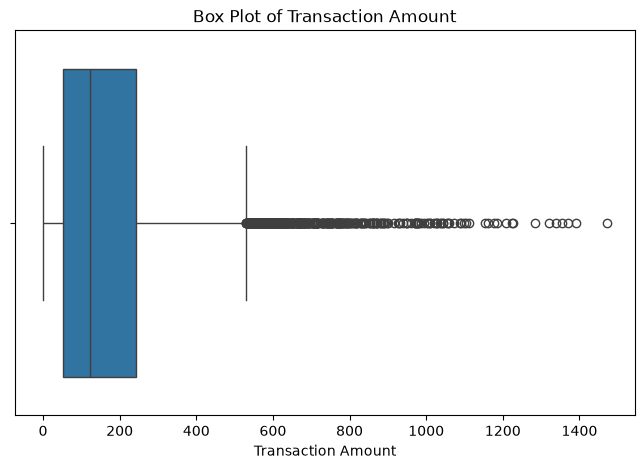

Number of outliers: 501
      transaction_id   amount  transaction_hour merchant_category  \
1                  2   541.82                 3            Travel   
11                12   630.64                18          Clothing   
33                34   535.26                 6          Clothing   
34                35   606.71                 7            Travel   
50                51   628.71                 4          Clothing   
...              ...      ...               ...               ...   
9851            9852   649.44                17            Travel   
9927            9928  1370.04                 7           Grocery   
9971            9972   671.94                16            Travel   
9972            9973   566.35                 0       Electronics   
9978            9979   541.45                 5           Grocery   

      foreign_transaction  location_mismatch  device_trust_score  \
1                       1                  0                  87   
11         

In [10]:
#3.Outlier Detection

#Detect outlier using IQR method
Q1 = df['amount'].quantile(0.25)
Q3 = df['amount'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

#Detect outlier using Box plot
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['amount'])
plt.title("Box Plot of Transaction Amount")
plt.xlabel("Transaction Amount")
plt.show()

outliers = df[(df['amount'] < lower_bound) | 
              (df['amount'] > upper_bound)]

print("Number of outliers:", len(outliers))

print(outliers)
outlier_percentage = (len(outliers) / len(df)) * 100
print("Outlier Percentage:", outlier_percentage, "%")
print(outliers['Class'].value_counts())



In [11]:
# 4.Feature Correlation

#Correlation Matrix
corr_data = df[['amount',
                'transaction_hour',
                'foreign_transaction',
                'location_mismatch',
                'device_trust_score',
                'velocity_last_24h',
                'cardholder_age',
                'Class']]

# Correlation matrix
corr = corr_data.corr()

print(corr)

                       amount  transaction_hour  foreign_transaction  \
amount               1.000000         -0.007369             0.004094   
transaction_hour    -0.007369          1.000000            -0.000255   
foreign_transaction  0.004094         -0.000255             1.000000   
location_mismatch    0.004232          0.004776             0.001426   
device_trust_score   0.009698          0.004054             0.012780   
velocity_last_24h   -0.001133         -0.003709            -0.007686   
cardholder_age       0.012735          0.012198             0.005408   
Class                0.028404         -0.138665             0.185597   

                     location_mismatch  device_trust_score  velocity_last_24h  \
amount                        0.004232            0.009698          -0.001133   
transaction_hour              0.004776            0.004054          -0.003709   
foreign_transaction           0.001426            0.012780          -0.007686   
location_mismatch          

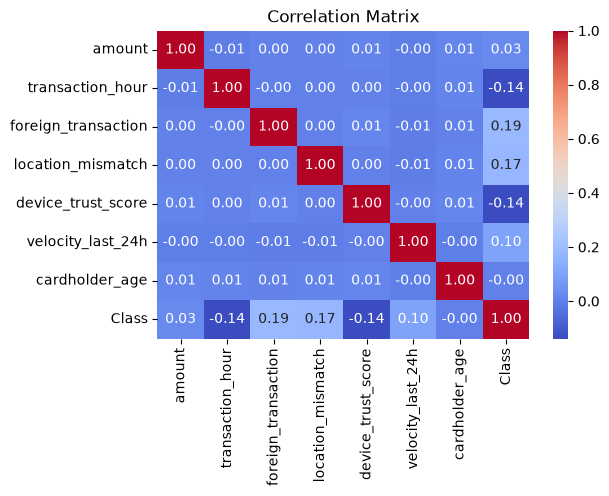

In [12]:
# Heatmap
plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix")
plt.show()

In [13]:
# 5.FEATURE SCALING

numeric_features = [
    'amount',
    'transaction_hour',
    'device_trust_score',
    'velocity_last_24h',
    'cardholder_age'
]

X_numeric = df[numeric_features]

print("Original Numerical Data:")
print(X_numeric.head())

# STANDARD SCALING

from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
standard_scaler = StandardScaler()

X_standard = standard_scaler.fit_transform(X_numeric)

X_standard = pd.DataFrame(
    X_standard,
    columns=numeric_features
)

print("\n========== STANDARD SCALED DATA ==========")
print(X_standard.head())

print("\nMean after Standard Scaling:")
print(X_standard.mean())

print("\nStandard Deviation after Standard Scaling:")
print(X_standard.std())

# MIN-MAX SCALING

minmax_scaler = MinMaxScaler()

X_minmax = minmax_scaler.fit_transform(X_numeric)

X_minmax = pd.DataFrame(
    X_minmax,
    columns=numeric_features
)

print("\n========== MIN-MAX SCALED DATA ==========")
print(X_minmax.head())

print("\nMinimum after Min-Max Scaling:")
print(X_minmax.min())

print("\nMaximum after Min-Max Scaling:")
print(X_minmax.max())

# COMPARISON OF BOTH METHODS

comparison = pd.DataFrame({
    'Original_Amount': df['amount'].head(),
    'Standard_Scaled_Amount': X_standard['amount'].head(),
    'MinMax_Scaled_Amount': X_minmax['amount'].head()
})

print("\n========== SCALING COMPARISON ==========")
print(comparison)

Original Numerical Data:
   amount  transaction_hour  device_trust_score  velocity_last_24h  \
0   84.47                22                  66                  3   
1  541.82                 3                  87                  1   
2  237.01                17                  49                  1   
3  164.33                 4                  72                  3   
4   30.53                15                  79                  0   

   cardholder_age  
0              40  
1              64  
2              61  
3              34  
4              44  

========== STANDARD SCALED DATA ==========
     amount  transaction_hour  device_trust_score  velocity_last_24h  \
0 -0.521597          1.503345            0.195528           0.691873   
1  2.086108         -1.241383            1.172909          -0.704299   
2  0.348151          0.781048           -0.595686          -0.704299   
3 -0.066254         -1.096923            0.474779           0.691873   
4 -0.829151          0.492130 

In [14]:
# 6. DATA ENCODING

# Check categorical columns

categorical_columns = df.select_dtypes(include=['object','string']).columns
print("Categorical Columns:")
print(categorical_columns)

# LABEL ENCODING

df_label = df.copy()

le = LabelEncoder()

# Apply Label Encoding to merchant_category
df_label['merchant_category_encoded'] = le.fit_transform(
    df_label['merchant_category']
)

print("\n========== LABEL ENCODING ==========")
print(
    df_label[
        ['merchant_category',
         'merchant_category_encoded']
    ].head(10)
)

# Show mapping
mapping = dict(
    zip(
        le.classes_,
        le.transform(le.classes_)
    )
)

print("\nLabel Encoding Mapping:")
print(mapping)

# ONE-HOT ENCODING

df_onehot = df.copy()

df_onehot = pd.get_dummies(
    df_onehot,
    columns=['merchant_category'],
    drop_first=False
)

print("\n========== ONE-HOT ENCODING ==========")
print(df_onehot.head())



Categorical Columns:
Index(['merchant_category'], dtype='str')

========== LABEL ENCODING ==========
  merchant_category  merchant_category_encoded
0       Electronics                          1
1            Travel                          4
2           Grocery                          3
3           Grocery                          3
4              Food                          2
5          Clothing                          0
6            Travel                          4
7       Electronics                          1
8           Grocery                          3
9           Grocery                          3

Label Encoding Mapping:
{'Clothing': np.int64(0), 'Electronics': np.int64(1), 'Food': np.int64(2), 'Grocery': np.int64(3), 'Travel': np.int64(4)}

========== ONE-HOT ENCODING ==========
   transaction_id  amount  transaction_hour  foreign_transaction  \
0               1   84.47                22                    0   
1               2  541.82                 3                

transaction_id           int64
amount                 float64
transaction_hour         int64
merchant_category          str
foreign_transaction      int64
location_mismatch        int64
device_trust_score       int64
velocity_last_24h        int64
cardholder_age           int64
Class                    int64
Hour                     int64
dtype: object
Class
0    9849
1     151
Name: count, dtype: int64
Class
0    98.49
1     1.51
Name: proportion, dtype: float64


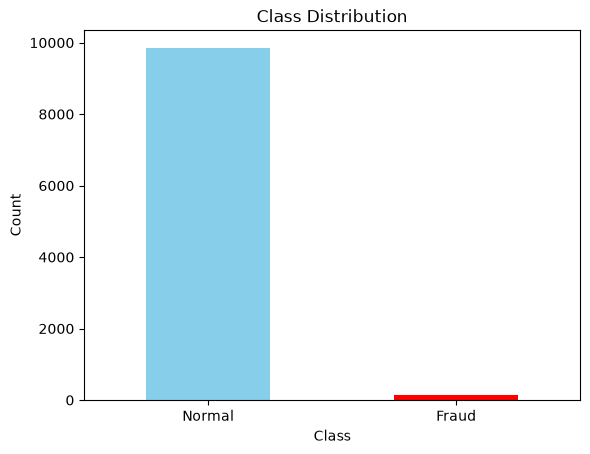

Normal Transactions : 9849
Fraud Transactions : 151
Imbalance Ratio = 65.23
Class
0    9849
1    9849
Name: count, dtype: int64


In [15]:
# 7.Class Imbalance Analysis
#To detect and remove data types str

print(df.dtypes)
df = pd.get_dummies(df, columns=['merchant_category'], drop_first=True)
X = df.drop('Class', axis=1).astype(float)  # force numeric
y = df['Class']

print(df['Class'].value_counts())
print(df['Class'].value_counts(normalize=True) * 100)
import matplotlib.pyplot as plt

df['Class'].value_counts().plot(
    kind='bar',
    color=['skyblue','red']
)

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks([0,1],['Normal','Fraud'],rotation=0)
plt.show()
counts = df['Class'].value_counts()

print("Normal Transactions :", counts[0])
print("Fraud Transactions :", counts[1])

ratio = counts[0] / counts[1]

print("Imbalance Ratio =", round(ratio,2))
from imblearn.over_sampling import SMOTE

X = df.drop('Class', axis=1)
y = df['Class']

smote = SMOTE(random_state=42)

X_resampled, y_resampled = smote.fit_resample(X, y)

print(y_resampled.value_counts())

(10000, 14)
Class
0    0.9849
1    0.0151
Name: proportion, dtype: float64
Confusion Matrix:
 [[1887   83]
 [   1   29]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.96      0.98      1970
           1       0.26      0.97      0.41        30

    accuracy                           0.96      2000
   macro avg       0.63      0.96      0.69      2000
weighted avg       0.99      0.96      0.97      2000

ROC-AUC: 0.9932825719120135
Average Precision (PR-AUC): 0.7364463488041411


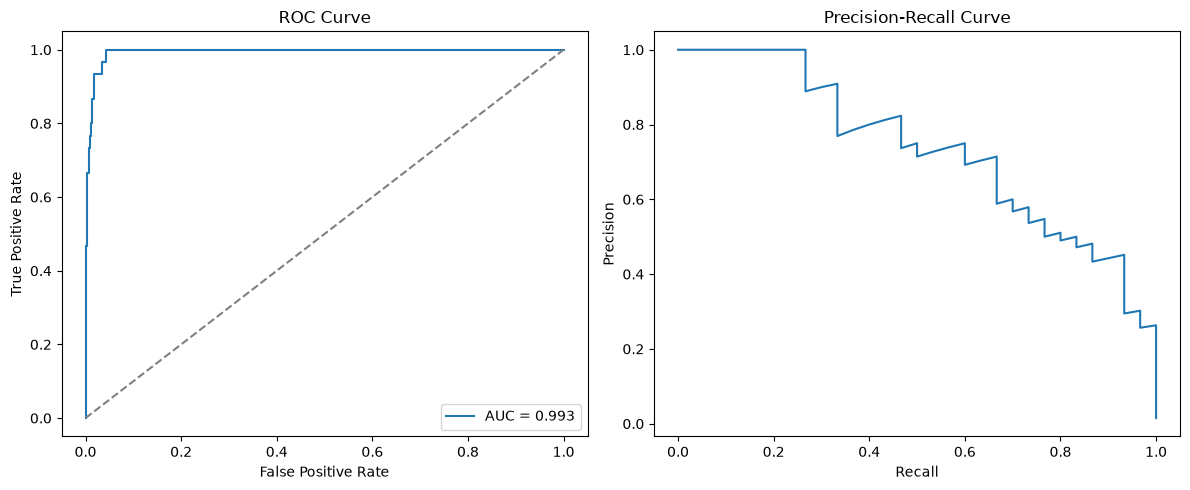

In [16]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve,
    average_precision_score
)
import matplotlib.pyplot as plt

print(df.shape)
print(df["Class"].value_counts(normalize=True))  # check class imbalance

# 1. Prepare features / target
# transaction_id is just an identifier, drop it

X = df.drop(columns=["transaction_id", "Class"])
y = df["Class"]

# 2. Train/test split (stratify to preserve fraud ratio)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
# 3. Scale numeric features (important for logistic regression)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#................................................
##4. Fit logistic regression
#    class_weight='balanced' matters a lot for fraud (rare positive class)
#...............................................

model = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

# 5. Evaluate

y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print("Average Precision (PR-AUC):", average_precision_score(y_test, y_proba))

# 6. Plots — ROC curve and Precision-Recall curve

fpr, tpr, _ = roc_curve(y_test, y_proba)
prec, rec, _ = precision_recall_curve(y_test, y_proba)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_proba):.3f}")
axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve")
axes[0].legend()

axes[1].plot(rec, prec)
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve")

plt.tight_layout()
plt.savefig("logistic_regression_eval.png", dpi=150)
plt.show()

In [17]:
#cLASS IMBALANCE HANDLING

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, average_precision_score
)
from sklearn.utils import resample

# 1. Check Fraud vs Non-Fraud count

class_counts = df["Class"].value_counts()
class_pct = df["Class"].value_counts(normalize=True) * 100

print("Class counts:\n", class_counts)
print("\nClass percentage:\n", class_pct)

# 2. Explain why the dataset is imbalanced

fraud_count = class_counts.get(1, 0)
nonfraud_count = class_counts.get(0, 0)
imbalance_ratio = nonfraud_count / fraud_count if fraud_count else float("inf")

print(f"\nNon-fraud transactions: {nonfraud_count}")
print(f"Fraud transactions: {fraud_count}")
print(f"Imbalance ratio (non-fraud : fraud) = {imbalance_ratio:.1f} : 1")

# 3. Prepare features 

y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4. Helper function: scale, train logistic regression, evaluate

def train_and_evaluate(X_tr, y_tr, X_te, y_te, label=""):
    scaler = StandardScaler()
    X_tr_scaled = scaler.fit_transform(X_tr)
    X_te_scaled = scaler.transform(X_te)

    model = LogisticRegression(max_iter=1000, random_state=42)
    model.fit(X_tr_scaled, y_tr)

    y_pred = model.predict(X_te_scaled)
    y_proba = model.predict_proba(X_te_scaled)[:, 1]

    print(f"\n===== Results: {label} =====")
    print("Confusion Matrix:\n", confusion_matrix(y_te, y_pred))
    print("\nClassification Report:\n", classification_report(y_te, y_pred, digits=3))
    print("ROC-AUC:", round(roc_auc_score(y_te, y_proba), 4))
    print("PR-AUC:", round(average_precision_score(y_te, y_proba), 4))

    return {
        "label": label,
        "roc_auc": roc_auc_score(y_te, y_proba),
        "pr_auc": average_precision_score(y_te, y_proba),
        "report": classification_report(y_te, y_pred, digits=3, output_dict=True)
    }

# 5. BEFORE balancing — train logistic regression on raw imbalanced data

results_before = train_and_evaluate(X_train, y_train, X_test, y_test, "BEFORE Balancing (Raw Imbalanced Data)")

# 6. Random Under-Sampling
#    Reduce majority class (non-fraud) to match minority class (fraud) size

train_df = X_train.copy()
train_df["Class"] = y_train.values

majority = train_df[train_df["Class"] == 0]
minority = train_df[train_df["Class"] == 1]

majority_downsampled = resample(
    majority, replace=False, n_samples=len(minority), random_state=42
)

undersampled_df = pd.concat([majority_downsampled, minority]).sample(frac=1, random_state=42)
X_train_under = undersampled_df.drop(columns=["Class"])
y_train_under = undersampled_df["Class"]

print("\nAfter Under-Sampling, class counts:\n", y_train_under.value_counts())

results_under = train_and_evaluate(
    X_train_under, y_train_under, X_test, y_test, "AFTER Random Under-Sampling"
)

# 7. Random Over-Sampling
#    Increase minority class (fraud) to match majority class (non-fraud) size

minority_upsampled = resample(
    minority, replace=True, n_samples=len(majority), random_state=42
)

oversampled_df = pd.concat([majority, minority_upsampled]).sample(frac=1, random_state=42)
X_train_over = oversampled_df.drop(columns=["Class"])
y_train_over = oversampled_df["Class"]

print("\nAfter Over-Sampling, class counts:\n", y_train_over.value_counts())

results_over = train_and_evaluate(
    X_train_over, y_train_over, X_test, y_test, "AFTER Random Over-Sampling"
)

# 8. Compare results before vs after balancing

comparison = pd.DataFrame([
    {
        "Method": r["label"],
        "ROC-AUC": round(r["roc_auc"], 4),
        "PR-AUC": round(r["pr_auc"], 4),
        "Fraud Recall": round(r["report"]["1"]["recall"], 4),
        "Fraud Precision": round(r["report"]["1"]["precision"], 4),
        "Fraud F1": round(r["report"]["1"]["f1-score"], 4),
    }
    for r in [results_before, results_under, results_over]
])

print("\n===== Comparison Table (Before vs After Balancing) =====")
print(comparison.to_string(index=False))

Class counts:
 Class
0    9849
1     151
Name: count, dtype: int64

Class percentage:
 Class
0    98.49
1     1.51
Name: proportion, dtype: float64

Non-fraud transactions: 9849
Fraud transactions: 151
Imbalance ratio (non-fraud : fraud) = 65.2 : 1

===== Results: BEFORE Balancing (Raw Imbalanced Data) =====
Confusion Matrix:
 [[1964    6]
 [  12   18]]

Classification Report:
               precision    recall  f1-score   support

           0      0.994     0.997     0.995      1970
           1      0.750     0.600     0.667        30

    accuracy                          0.991      2000
   macro avg      0.872     0.798     0.831      2000
weighted avg      0.990     0.991     0.991      2000

ROC-AUC: 0.9944
PR-AUC: 0.8198

After Under-Sampling, class counts:
 Class
0    121
1    121
Name: count, dtype: int64

===== Results: AFTER Random Under-Sampling =====
Confusion Matrix:
 [[1865  105]
 [   0   30]]

Classification Report:
               precision    recall  f1-score   suppor

In [19]:
#ALGORITHM COMPARISON

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, f1_score, roc_curve, auc,
                              precision_recall_curve)
from imblearn.over_sampling import SMOTE
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
df = pd.read_csv("C:/Users/HP/Desktop/Internship Final Submission/Credit Card Fraud Analysis/1_credit_card_fraud_ Original Dataset.csv")
df = df.drop(columns=["transaction_id"])
df = pd.get_dummies(df, columns=["merchant_category"], drop_first=True)
X = df.drop(columns=["Class"])
y = df["Class"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
scaler = StandardScaler()
num_cols = ["amount", "transaction_hour", "device_trust_score",
            "velocity_last_24h", "cardholder_age"]
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)
print("Original train class counts:", y_train.value_counts().to_dict())
print("After SMOTE:", y_train_res.value_counts().to_dict())
models = {
    "Decision Tree": DecisionTreeClassifier(max_depth=6, class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=10, class_weight="balanced",
                                             random_state=42, n_jobs=-1),
    "KNN": KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
}
results = {}
for name, model in models.items():
    model.fit(X_train_res, y_train_res)
    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:, 1]
    results[name] = (pred, prob)
    print(f"===== {name} =====")
    print(classification_report(y_test, pred, digits=3))
    print("Confusion matrix:\n", confusion_matrix(y_test, pred))
    print("ROC-AUC:", round(roc_auc_score(y_test, prob), 4))
    print()
summary = []
for name, (pred, prob) in results.items():
    report = classification_report(y_test, pred, output_dict=True)
    summary.append({
        "Model": name,
        "Precision (fraud)": round(report["1"]["precision"], 3),
        "Recall (fraud)": round(report["1"]["recall"], 3),
        "F1 (fraud)": round(f1_score(y_test, pred), 3),
        "ROC-AUC": round(roc_auc_score(y_test, prob), 3),
    })
summary_df = pd.DataFrame(summary)
print(summary_df.to_string(index=False))
summary_df.to_csv("credit_card_fraud_10k.csv", index=False)
plt.figure(figsize=(7, 6))
for name, (pred, prob) in results.items():
    fpr, tpr, _ = roc_curve(y_test, prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc(fpr, tpr):.3f})")
plt.plot([0, 1], [0, 1], "k--", alpha=0.5)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison - Credit Card Fraud Detection")
plt.legend()
plt.tight_layout()
plt.savefig("roc_comparison.png", dpi=150)
plt.close()
plt.figure(figsize=(7, 6))
for name, (pred, prob) in results.items():
    prec, rec, _ = precision_recall_curve(y_test, prob)
    plt.plot(rec, prec, label=name)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend()
plt.tight_layout()
plt.savefig("pr_comparison.png", dpi=150)
plt.close()
print("\nSaved: model_comparison.csv, roc_comparison.png, pr_comparison.png")

Original train class counts: {0: 7879, 1: 121}
After SMOTE: {0: 7879, 1: 7879}
===== Decision Tree =====
              precision    recall  f1-score   support

           0      0.997     0.948     0.972      1970
           1      0.195     0.833     0.316        30

    accuracy                          0.946      2000
   macro avg      0.596     0.891     0.644      2000
weighted avg      0.985     0.946     0.962      2000

Confusion matrix:
 [[1867  103]
 [   5   25]]
ROC-AUC: 0.9347

===== Random Forest =====
              precision    recall  f1-score   support

           0      0.998     0.993     0.995      1970
           1      0.650     0.867     0.743        30

    accuracy                          0.991      2000
   macro avg      0.824     0.930     0.869      2000
weighted avg      0.993     0.991     0.992      2000

Confusion matrix:
 [[1956   14]
 [   4   26]]
ROC-AUC: 0.9968

===== KNN =====
              precision    recall  f1-score   support

           0      